# Installing & Importing Libraries

In [ ]:
#specific versions of libraries is used
!pip uninstall -y numpy scipy scikit-learn xgboost catboost lightgbm scikeras
!pip install numpy==1.26
!pip install scipy==1.15.2
!pip install scikit-learn==1.5.2
!pip install xgboost==2.1.1
!pip install catboost lightgbm scikeras --upgrade --force-reinstall
!pip install -q category_encoders

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import catboost as cat
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, make_scorer,confusion_matrix
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
import category_encoders as ce
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from category_encoders import TargetEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from tensorflow.keras.layers import Input
import warnings
warnings.filterwarnings("ignore")


# Loading the Dataset

In [ ]:
# Loading dataset to pandas dataFrame
df = pd.read_csv('/content/sample_data/credit_card_dataset.csv')

#Dataset Cleaning &  Preprocessing

In [ ]:
df.head()

,sn,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,21-06-2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,19-03-1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,21-06-2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",17-01-1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,21-06-2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",21-10-1970,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,21-06-2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,25-07-1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,21-06-2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,06-07-1955,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [ ]:
df['merchant']  #The name are prefixed with fraud; this can act as noise to the model

0                        fraud_Kirlin and Sons
1                         fraud_Sporer-Keebler
2         fraud_Swaniawski, Nitzsche and Welch
3                            fraud_Haley Group
4                        fraud_Johnston-Casper
                          ...                 
555714                   fraud_Reilly and Sons
555715                    fraud_Hoppe-Parisian
555716                         fraud_Rau-Robel
555717                   fraud_Breitenberg LLC
555718                       fraud_Dare-Marvin
Name: merchant, Length: 555719, dtype: str

In [ ]:
# Remove the 'fraud_' prefix from the merchant column
df['merchant'] = df['merchant'].str.replace('^fraud_', '', regex=True)

# Check
df['merchant'].head()


0                   Kirlin and Sons
1                    Sporer-Keebler
2    Swaniawski, Nitzsche and Welch
3                       Haley Group
4                   Johnston-Casper
Name: merchant, dtype: str

In [ ]:
df['is_fraud'].value_counts()  #Ration of fraud to non fraud in dataset

is_fraud
0    553574
1      2145
Name: count, dtype: int64

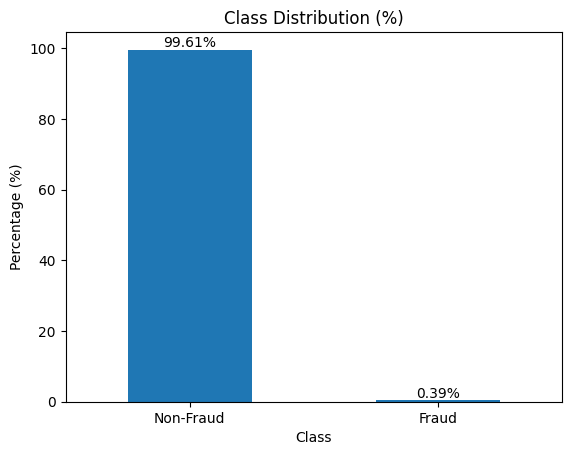

In [ ]:


# Count values
counts = df['is_fraud'].value_counts()

# Convert to percentage
percentages = (counts / counts.sum()) * 100

# Rename classes
percentages.index = percentages.index.map({
    0: 'Non-Fraud',
    1: 'Fraud'
})

# Plot
ax = percentages.plot(kind='bar')

plt.ylabel('Percentage (%)')
plt.xlabel('Class')
plt.title('Class Distribution (%)')
plt.xticks(rotation=0)

# Add percentage labels on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()


In [ ]:
df[df["is_fraud"]==1].describe() #Exploratorory Descriptive Analysis(EDA) to
                                #understand underlying pattern difference between fraud(1) and Non-fraud(0)

,sn,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,2145.000000,2.145000e+03,2145.000000,2145.000000,2145.000000,2145.000000,2.145000e+03,2.145000e+03,2145.000000,2145.000000,2145.0
mean,242057.088112,3.854275e+17,528.356494,47862.900233,39.019971,-90.445556,6.452932e+04,1.379587e+09,39.018618,-90.465222,1.0
std,135455.280233,1.276313e+18,392.747594,26706.283776,5.076671,14.147521,2.192075e+05,4.546697e+06,5.093782,14.159252,0.0
min,1685.000000,6.048700e+10,1.780000,1257.000000,20.082700,-155.488000,2.300000e+01,1.371852e+09,19.161782,-156.480766,1.0
25%,131562.000000,3.056060e+13,214.510000,23937.000000,34.957200,-96.743000,1.131000e+03,1.375756e+09,35.017480,-96.697100,1.0
50%,245890.000000,2.358120e+15,371.940000,47987.000000,39.893600,-88.093500,2.870000e+03,1.379548e+09,39.744929,-88.040722,1.0
75%,346223.000000,4.335530e+15,907.770000,68031.000000,42.180800,-79.785600,1.233500e+04,1.383350e+09,42.208725,-79.909134,1.0
max,517571.000000,4.989850e+18,1320.920000,99921.000000,55.473200,-67.950300,1.577385e+06,1.387754e+09,56.214113,-66.960745,1.0


In [ ]:
df[df["is_fraud"]==0].describe()

,sn,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,553574.000000,5.535740e+05,553574.000000,553574.000000,553574.000000,553574.000000,5.535740e+05,5.535740e+05,553574.000000,553574.000000,553574.0
mean,277997.725990,4.179643e+17,67.614408,48846.424285,38.541406,-90.230495,8.831369e+04,1.380683e+09,38.540954,-90.230474,0.0
std,160496.162903,1.309965e+18,152.471931,26855.813540,5.061194,13.720111,3.006593e+05,5.203038e+06,5.095755,13.731399,0.0
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.0
25%,139011.250000,1.800430e+14,9.600000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376031e+09,34.754055,-96.906402,0.0
50%,278009.500000,3.521420e+15,47.150000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380770e+09,39.374616,-87.443645,0.0
75%,417073.750000,4.642260e+15,82.620000,72042.000000,41.894800,-80.175200,1.968500e+04,1.385872e+09,41.953397,-80.265911,0.0
max,555718.000000,4.992350e+18,22768.110000,99783.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,0.0


In [ ]:
df.info() #EDA to see Feature types

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   sn                     555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  float64
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

In [ ]:
df.isnull().sum() #checking for missing data

,0
sn,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [ ]:
df.duplicated().sum() #checking for duplicated data

np.int64(0)

In [ ]:
df[df.duplicated()] #checking for duplicated data

,sn,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud


In [ ]:
df=df.drop_duplicates() #remove duplicates if any

In [ ]:
df.dropna(inplace=True) #Remove missing data if any

#Feature Engineering

### dropping meaningless features

In [ ]:
drop_cols = ['sn','first','last','street','trans_num','cc_num']   #this columns add no value to model
df = df.drop(columns=drop_cols)

In [ ]:
df.info()

###To date time

In [ ]:
df['Transaction_Date'] = pd.to_datetime(df['trans_date_trans_time'])  #converting date to datetime

/tmp/ipython-input-12682/2142689047.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Transaction_Date'] = pd.to_datetime(df['trans_date_trans_time'])  #converting date to datetime


In [ ]:
df['Year'] = df['Transaction_Date'].dt.year       #Extracting Datetime components. This improves model flexibility
df['Month'] = df['Transaction_Date'].dt.month
df['Day'] = df['Transaction_Date'].dt.day
df['Hour'] = df['Transaction_Date'].dt.hour
df['IsWeekend'] = df['Transaction_Date'].dt.dayofweek >= 5


In [ ]:
df['dob'] = pd.to_datetime(df['dob'])   #customer age is extracted.

df['age'] = (
    df['Year'] -
    df['dob'].dt.year
)

/tmp/ipython-input-12682/1185525267.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['dob'] = pd.to_datetime(df['dob'])


In [ ]:
df = df.drop(
    columns=['trans_date_trans_time', 'dob', 'Transaction_Date'] # Improved features are extracted already
                                                                  #and original features are drop as they are not useful.
)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 21 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   merchant    555719 non-null  str    
 1   category    555719 non-null  str    
 2   amt         555719 non-null  float64
 3   gender      555719 non-null  str    
 4   city        555719 non-null  str    
 5   state       555719 non-null  str    
 6   zip         555719 non-null  int64  
 7   lat         555719 non-null  float64
 8   long        555719 non-null  float64
 9   city_pop    555719 non-null  int64  
 10  job         555719 non-null  str    
 11  unix_time   555719 non-null  int64  
 12  merch_lat   555719 non-null  float64
 13  merch_long  555719 non-null  float64
 14  is_fraud    555719 non-null  int64  
 15  Year        555719 non-null  int32  
 16  Month       555719 non-null  int32  
 17  Day         555719 non-null  int32  
 18  Hour        555719 non-null  int32  
 19  IsWeekend   5

# Splitting the dataset into Train & Test

In [ ]:
#To avoid data leakage and overfitting data is splitted before encoding
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Encoding of categorical Features and Scaling of Numerical Features

In [ ]:
#Conversion of strings or categorical to numerical values as models understand numeric values only.
high_card_cat = ['merchant', 'city', 'job']
low_card_cat = ['category', 'state', 'gender']
numeric_features = [col for col in X_train.columns
                    if col not in high_card_cat + low_card_cat]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('low_cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card_cat),
        ('high_cat', TargetEncoder(), high_card_cat)
    ]
)


In [ ]:
sample = X_train_scaled[:5].toarray()  # preview of data after encoding

pd.DataFrame(
    sample,
    columns=preprocessor.get_feature_names_out()
)


,num__amt,num__zip,num__lat,num__long,num__city_pop,num__unix_time,num__merch_lat,num__merch_long,num__Year,num__Month,...,cat_low__state_UT,cat_low__state_VA,cat_low__state_VT,cat_low__state_WA,cat_low__state_WI,cat_low__state_WV,cat_low__state_WY,cat_high__merchant,cat_high__city,cat_high__job
0,-0.331864,-0.008100,1.196075,0.433181,-0.290412,-0.408693,1.016830,0.377944,0.0,-0.257707,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.512859e-03,6.856500e-18,0.000000
1,0.799304,-0.751926,-0.462795,0.663717,-0.222829,0.786599,-0.332244,0.730530,0.0,0.753338,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.255139e-03,0.000000e+00,0.000000
2,-0.165382,1.440457,-0.615006,-1.143874,-0.290215,-0.043935,-0.741493,-1.210834,0.0,-0.257707,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.688282e-03,2.157021e-10,0.005583
3,-0.442203,-0.342127,-1.362785,0.004310,-0.289305,-0.048320,-1.515838,-0.026967,0.0,-0.257707,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.136364e-02,0.000000e+00,0.000000
4,-0.385475,-1.356944,0.697114,1.150038,-0.291969,1.487906,0.738893,1.113650,0.0,1.258860,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.792796e-15,0.000000e+00,0.012012


## Previewing SMOTE

In [ ]:
#This is just a preview of SMOTE as smote will be applied via Pipeline

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)


In [ ]:
(pd.Series(y_resampled)
 .value_counts(normalize=True)
 .mul(100)
 .rename({0: 'Non-Fraud', 1: 'Fraud'})
 .round(2)
)


,proportion
is_fraud,
Non-Fraud,50.0
Fraud,50.0


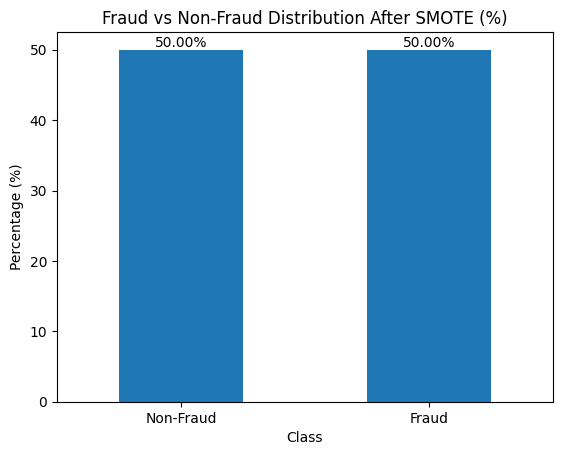

In [ ]:

# Calculate percentages after SMOTE
percentages_smote = (
    pd.Series(y_resampled)
    .value_counts(normalize=True)
    .mul(100)
    .rename({0: 'Non-Fraud', 1: 'Fraud'})
)

# Plot
ax = percentages_smote.plot(kind='bar')

plt.ylabel('Percentage (%)')
plt.xlabel('Class')
plt.title('Fraud vs Non-Fraud Distribution After SMOTE (%)')
plt.xticks(rotation=0)

# Add percentage labels on bars
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

# Initializing  Evaluation metrics

In [ ]:
#Initialize Evaluation metrics
def evaluate(y_true, y_pred, y_prob):
    acc, prec, rec, f1, auc = (
        accuracy_score(y_true,y_pred),
        precision_score(y_true,y_pred,zero_division=0),
        recall_score(y_true,y_pred,zero_division=0),
        f1_score(y_true,y_pred,zero_division=0),
        roc_auc_score(y_true,y_prob) if len(set(y_true))>1 else 0
    )
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,'auc':auc,'tn':tn,'fp':fp,'fn':fn,'tp':tp}

# MODELLING

# Initializing classifiers

In [ ]:
#RF,xgboost,catboost,lightboost and MLP are initialized and reused via a pipeline

rf = RandomForestClassifier(             #  ------------------ random_forest
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=1
)

# compute scale_pos_weight
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train) #  ------------------ xg_Boost
xgbc = XGBClassifier(
    n_estimators=100,
    n_jobs=1,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)


cat_clf = CatBoostClassifier(              #  ------------------ cat_Boost
    iterations=100,
    random_state=42,
    auto_class_weights="Balanced",
    #thread_count=1,
    verbose=0
)

lgb_clf = lgb.LGBMClassifier(            #  -------------------- Light_Boost
    n_estimators=100,
    random_state=42,
    n_jobs=1,
    verbose=0,
    class_weight='balanced'
)

# ------------------------------           #  ------------------Multilayer Perceptron (MLP)
def build_mlp(meta):
    n_features = meta["n_features_in_"]

    model = Sequential([
        Input(shape=(n_features,)),               # Input layer
        Dense(64, activation='relu'),             # Hidden Layer 1
        Dropout(0.2),
        Dense(32, activation='relu'),             # Hidden Layer 2
        Dropout(0.2),
        Dense(1, activation='sigmoid')            # Output layer
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ------------------------------
# KerasClassifier
# ------------------------------
mlp_clf = KerasClassifier(
    model=build_mlp,
    epochs=20,
    batch_size=32,
    verbose=0,
    validation_split=0.1,
)



# Base Models On Imbalanced dataset

##Random Forest

In [ ]:

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),   # TargetEncoder + StandardScaler + OneHot
    ('model', rf)   # ← RF defined here ONLY ONCE
])


rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

rf_metrics = evaluate(y_test, rf_pred, rf_prob)
print("RF:", rf_metrics)



RF: {'accuracy': 0.9986593968185418, 'precision': 0.9861111111111112, 'recall': 0.662004662004662, 'f1': 0.7921896792189679, 'auc': 0.9879354022965999}


RF: {'accuracy': 0.9986593968185418, 'precision': 0.9861111111111112, 'recall': 0.662004662004662, 'f1': 0.7921896792189679, 'auc': 0.9879354022965999}


##xboost

In [ ]:

# Pipeline
xgb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', xgbc)
])

# Fit
xgb_pipeline.fit(X_train, y_train)

# Predict
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
xgb_metrics = evaluate(y_test, xgb_pred, xgb_prob)
print('XGB:', xgb_metrics)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:07:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB: {'accuracy': 0.9981015619376664, 'precision': 0.7064393939393939, 'recall': 0.8694638694638694, 'f1': 0.7795193312434692, 'auc': 0.9935185439588636}


XGB: {'accuracy': 0.9981015619376664, 'precision': 0.7064393939393939, 'recall': 0.8694638694638694, 'f1': 0.7795193312434692, 'auc': 0.9935185439588636}


## CatBoost

In [ ]:


# Pipeline
cat_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', cat_clf)
])

# Fit
cat_pipeline.fit(X_train, y_train)

# Predict
cat_pred = cat_pipeline.predict(X_test)
cat_prob = cat_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
cat_metrics = evaluate(y_test, cat_pred, cat_prob)
print("Cat:", cat_metrics)

Cat: {'accuracy': 0.9970578708702225, 'precision': 0.5791925465838509, 'recall': 0.8694638694638694, 'f1': 0.6952469711090401, 'auc': 0.9961341974348342}


Cat: {'accuracy': 0.9970578708702225, 'precision': 0.5791925465838509, 'recall': 0.8694638694638694, 'f1': 0.6952469711090401, 'auc': 0.9961341974348342}


##LightBoost

In [ ]:


# Pipeline
lgb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', lgb_clf)
])

# Fit
lgb_pipeline.fit(X_train, y_train)

# Predict
lgb_pred = lgb_pipeline.predict(X_test)
lgb_prob = lgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
lgb_metrics = evaluate(y_test, lgb_pred, lgb_prob)
print('LGB:', lgb_metrics)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGB: {'accuracy': 0.9962571078960628, 'precision': 0.5087483176312247, 'recall': 0.8811188811188811, 'f1': 0.6450511945392492, 'auc': 0.9905536138431409}



LGB: {'accuracy': 0.9962571078960628, 'precision': 0.5087483176312247, 'recall': 0.8811188811188811, 'f1': 0.6450511945392492, 'auc': 0.9905536138431409}


##Multilayer Perceptron (MLP)

In [ ]:


# mlp single Pipeline
mlp_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', mlp_clf)  # mlp single model
])

# Train the pipeline
mlp_pipeline.fit(X_train, y_train)

#  EVALUATE PIPELINE
mlp_prob = mlp_pipeline.predict_proba(X_test)[:, 1]
mlp_pred = (mlp_prob > 0.5).astype(int)

metrics = evaluate_overall(y_test, mlp_pred, mlp_prob)

print("\n=== MLP Pipeline Metrics ===")
for key, value in metrics.items():
    print(f"{key:12}: {value:.4f}")

🚀 Training MLP Pipeline (exactly matching your original parameters)...
Epoch 1/20
12504/12504 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9966 - loss: 0.0163 - val_accuracy: 0.9973 - val_loss: 0.0105
Epoch 2/20
12504/12504 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9977 - loss: 0.0102 - val_accuracy: 0.9983 - val_loss: 0.0078
Epoch 3/20
12504/12504 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9981 - loss: 0.0082 - val_accuracy: 0.9987 - val_loss: 0.0058
Epoch 4/20
12504/12504 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9983 - loss: 0.0072 - val_accuracy: 0.9984 - val_loss: 0.0057
Epoch 5/20
12504/12504 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9983 - loss: 0.0068 - val_accuracy: 0.9987 - val_loss: 0.0060
Epoch 6/20
12504/12504 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9984 - loss: 0.0065 - val_accuracy: 0.9986 - val_loss: 0.0052
Epoch 7/20
12504/12504 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.9985 - loss: 0.0061 - val_accuracy: 0.9988 - val_loss: 0.004

> === MLP Pipeline Metrics ===
Accuracy    : 0.9989
Precision   : 0.9669
Recall      : 0.7483
F1          : 0.8436
ROC AUC     : 0.9960

# Base models ON smote Dataset

## Random Forest + SMOTE

In [ ]:
rf_pipeline_smote = ImbPipeline([
    ('preprocessor', preprocessor),   # TargetEncoder + StandardScaler + OneHot
    ('smote', SMOTE(random_state=42)),
    ('model', rf)   # ← RF defined here ONLY ONCE
])


rf_pipeline_smote.fit(X_train, y_train)

rf_pred = rf_pipeline_smote.predict(X_test)
rf_prob = rf_pipeline_smote.predict_proba(X_test)[:, 1]

rf_metrics_smote = evaluate(y_test, rf_pred, rf_prob)
print("RF:", rf_metrics_smote)


RF: {'accuracy': 0.9988033542071547, 'precision': 0.9404761904761905, 'recall': 0.7365967365967366, 'f1': 0.8261437908496732, 'auc': 0.9928029263485163}


>RF: {'accuracy': 0.9988033542071547, 'precision': 0.9404761904761905, 'recall': 0.7365967365967366, 'f1': 0.8261437908496732, 'auc': 0.9928029263485163}


##xboost + SMOTE

In [ ]:


# Pipeline
xgb_pipeline_smote = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', xgbc)
])

# Fit
xgb_pipeline_smote.fit(X_train, y_train)

# Predict
xgb_pred = xgb_pipeline_smote.predict(X_test)
xgb_prob = xgb_pipeline_smote.predict_proba(X_test)[:, 1]

# Evaluate
xgb_metrics = evaluate(y_test, xgb_pred, xgb_prob)
print('XGB:', xgb_metrics)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:08:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB: {'accuracy': 0.9973007989635068, 'precision': 0.6022187004754358, 'recall': 0.8857808857808858, 'f1': 0.7169811320754716, 'auc': 0.9931777731669347}


>XGB: {'accuracy': 0.9973007989635068, 'precision': 0.6022187004754358, 'recall': 0.8857808857808858, 'f1': 0.7169811320754716, 'auc': 0.9931777731669347}


## CatBoost + SMOTE

In [ ]:


# Pipeline
cat_pipeline_smote = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', cat_clf)
])

# Fit
cat_pipeline_smote.fit(X_train, y_train)

# Predict
cat_pred = cat_pipeline_smote.predict(X_test)
cat_prob = cat_pipeline_smote.predict_proba(X_test)[:, 1]

# Evaluate
cat_metrics = evaluate(y_test, cat_pred, cat_prob)
print("Cat:", cat_metrics)

Cat: {'accuracy': 0.998263513999856, 'precision': 0.7408163265306122, 'recall': 0.8461538461538461, 'f1': 0.7899891186071817, 'auc': 0.9942247188148827}


>Cat: {'accuracy': 0.998263513999856, 'precision': 0.7408163265306122, 'recall': 0.8461538461538461, 'f1': 0.7899891186071817, 'auc': 0.9942247188148827}


##LightBoost + SMOTE

In [ ]:


# Pipeline
lgb_pipeline_smote = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', lgb_clf)
])

# Fit
lgb_pipeline_smote.fit(X_train, y_train)

# Predict
lgb_pred = lgb_pipeline_smote.predict(X_test)
lgb_prob = lgb_pipeline_smote.predict_proba(X_test)[:, 1]

# Evaluate
lgb_metrics = evaluate(y_test, lgb_pred, lgb_prob)
print('LGB:', lgb_metrics)

[LightGBM] [Info] Number of positive: 442859, number of negative: 442859
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.351115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18768
[LightGBM] [Info] Number of data points in the train set: 885718, number of used features: 82
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGB: {'accuracy': 0.9981285539480313, 'precision': 0.7153996101364523, 'recall': 0.8554778554778555, 'f1': 0.7791932059447984, 'auc': 0.9904760190358348}


>LGB: {'accuracy': 0.9981285539480313, 'precision': 0.7153996101364523, 'recall': 0.8554778554778555, 'f1': 0.7791932059447984, 'auc': 0.9904760190358348}


##Multilayer Perceptron (MLP) + SMOTE

In [ ]:

# Full Pipeline

mlp_pipeline_smote = ImbPipeline([
    ('preprocess', preprocessor),   #  TargetEncoder + OneHot + StandardScaler
    ('smote', SMOTE(random_state=42)),
    ('model', mlp_clf)
])

# Train the pipeline

mlp_pipeline_smote.fit(X_train, y_train)


# EVALUATE PIPELINE
mlp_prob = mlp_pipeline_smote.predict_proba(X_test)[:, 1]
mlp_pred = (mlp_prob > 0.5).astype(int)

metrics = evaluate_overall(y_test, mlp_pred, mlp_prob)

print("\n=== MLP Pipeline Metrics ===")
for key, value in metrics.items():
    print(f"{key:12}: {value:.4f}")

🚀 Training MLP Pipeline (exactly matching your original parameters)...
Epoch 1/20
24911/24911 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - accuracy: 0.9801 - loss: 0.0543 - val_accuracy: 0.9991 - val_loss: 0.0084
Epoch 2/20
24911/24911 ━━━━━━━━━━━━━━━━━━━━ 68s 3ms/step - accuracy: 0.9942 - loss: 0.0180 - val_accuracy: 0.9996 - val_loss: 0.0044
Epoch 3/20
24911/24911 ━━━━━━━━━━━━━━━━━━━━ 68s 3ms/step - accuracy: 0.9958 - loss: 0.0135 - val_accuracy: 0.9999 - val_loss: 0.0025
Epoch 4/20
24911/24911 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - accuracy: 0.9965 - loss: 0.0114 - val_accuracy: 0.9996 - val_loss: 0.0028
Epoch 5/20
24911/24911 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - accuracy: 0.9969 - loss: 0.0104 - val_accuracy: 0.9988 - val_loss: 0.0066
Epoch 6/20
24911/24911 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - accuracy: 0.9972 - loss: 0.0095 - val_accuracy: 0.9991 - val_loss: 0.0033
Epoch 7/20
24911/24911 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - accuracy: 0.9973 - loss: 0.0092 - val_accuracy: 0.9997 - val_loss: 0.002

> === MLP Pipeline Metrics ===
Accuracy    : 0.9983
Precision   : 0.7305
Recall      : 0.8718
F1          : 0.7949
ROC AUC     : 0.9899

# HYBRID MODEL STACKING

### Initializing Stack

In [ ]:
stack_model = StackingClassifier(    #Hybrid model: stacking all base-models using LR meta-learner
        estimators=[
            ('rf', rf),
            ('xgb', xgbc),
            ('cat', cat_clf),
            ('lgbm', lgb_clf),
            ('mlp', mlp_clf)
        ],
        final_estimator=LogisticRegression(),
        n_jobs=1
    )


## HYBRID STACK ON IMBALANCED DATASET

In [ ]:
pipeline_no_smote = Pipeline([
    ('preprocess', preprocessor),  # Hybrid model pipeline
    ('stack', stack_model)
])




In [ ]:
#  Fit pipeline on training data
pipeline_no_smote.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('stack', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [ ]:
# Predictions
stack_pred = pipeline_no_smote.predict(X_test)

# Probabilities (needed for ROC, AUC, PR, etc.)
stack_prob = pipeline_no_smote.predict_proba(X_test)[:, 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("Accuracy :", accuracy_score(y_test, stack_pred))
print("Precision:", precision_score(y_test, stack_pred))
print("Recall   :", recall_score(y_test, stack_pred))
print("F1-score :", f1_score(y_test, stack_pred))
print("ROC-AUC  :", roc_auc_score(y_test, stack_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, stack_pred))

Accuracy : 0.9989473115957677
Precision: 0.8861386138613861
Recall   : 0.8344988344988346
F1-score : 0.8595438175270108
ROC-AUC  : 0.9985703438352131


Accuracy : 0.9989743036061326
Precision: 0.8947368421052632
Recall   : 0.8321678321678322
F1-score : 0.8623188405797102
ROC-AUC  : 0.9980110211786137


In [ ]:
import joblib
# Save the trained pipeline
joblib.dump(pipeline_no_smote, "hybrid_model_stack_IMBD.pkl")


['hybrid_model_stack_IMBD.pkl']

In [ ]:
from google.colab import files

# Downoad model to local enviroment
files.download('/content/hybrid_model_stack_IMBD.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## HYBRID STACK + SMOTE

In [ ]:

pipeline_with_smote = ImbPipeline([
    ('preprocess', preprocessor),   # Hybrid model pipeline with SMOTE dataset
    ('smote', SMOTE(random_state=42)),
    ('stack', stack_model)
])

pipeline_with_smote.fit(X_train, y_train)



,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

In [ ]:
# Predictions
stack_pred_smote = pipeline_with_smote.predict(X_test)

# Probabilities (needed for ROC, AUC, PR, etc.)
stack_prob_smote = pipeline_with_smote.predict_proba(X_test)[:, 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("Accuracy :", accuracy_score(y_test, stack_pred_smote))
print("Precision:", precision_score(y_test, stack_pred_smote))
print("Recall   :", recall_score(y_test, stack_pred_smote))
print("F1-score :", f1_score(y_test, stack_pred_smote))
print("ROC-AUC  :", roc_auc_score(y_test, stack_prob_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, stack_pred_smote))

Accuracy : 0.9991002663211689
Precision: 0.9272727272727272
Recall   : 0.8321678321678322
F1-score : 0.8771498771498771
ROC-AUC  : 0.9974167908594137
Confusion Matrix:
 [[110687     28]
 [    72    357]]


> Accuracy : 0.9991002663211689
Precision: 0.9272727272727272
Recall   : 0.8321678321678322
F1-score : 0.8771498771498771
ROC-AUC  : 0.9974167908594137
Confusion Matrix:
 [[110687     28]
 [    72    357]]


In [ ]:
import joblib
# Save the trained pipeline
joblib.dump(pipeline_with_smote, "Hybrid_Stack_on_SMOTE.pkl")


['Hybrid_Stack_on_SMOTE.pkl']

In [ ]:
from google.colab import files

# Downoad model to local enviroment
files.download('/content/Hybrid_Stack_on_SMOTE.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

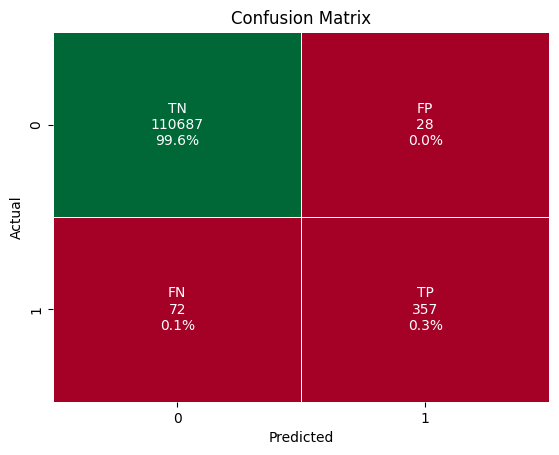

In [ ]:

# Plot
tn, fp, fn, tp = confusion_matrix(y_test, stack_pred_smote).ravel()
labels = [[f'TN\n{tn}\n{tn/len(y_test)*100:.1f}%', f'FP\n{fp}\n{fp/len(y_test)*100:.1f}%'],
          [f'FN\n{fn}\n{fn/len(y_test)*100:.1f}%', f'TP\n{tp}\n{tp/len(y_test)*100:.1f}%']]

sns.heatmap([[tn, fp],[fn, tp]], annot=labels, fmt='', cmap='RdYlGn', cbar=False, linewidths=0.5)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

# TOP 2 BM peformers + MLP; STACKING  

###+Imbalanced Data

In [ ]:
pipeline_stack_bp = StackingClassifier(
    estimators=[
         ('rf', rf),         # Hybrid model of best performerming basemodels   on Imbalanced data
         ('xgb', xgbc),
        ('mlp', mlp_clf)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=1,

)



In [ ]:
pipeline_stack_bp = Pipeline([  #pipeline
    ('preprocess', preprocessor),
    ('stack', pipeline_stack_bp)
])

#  Fit pipeline on training data
pipeline_stack_bp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('stack', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [ ]:
# Predictions
y_stack_bp_pred = pipeline_stack_bp.predict(X_test)

# Probabilities (needed for ROC, AUC, PR, etc.)
y_stack_bp_prob = pipeline_stack_bp.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_stack_bp_pred))
print("Precision:", precision_score(y_test, y_stack_bp_pred))
print("Recall   :", recall_score(y_test, y_stack_bp_pred))
print("F1-score :", f1_score(y_test, y_stack_bp_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_stack_bp_prob))
#print("Confusion Matrix:\n", confusion_matrix(y_test, stack_pred))

Accuracy : 0.9990822716475923
Precision: 0.9203084832904884
Recall   : 0.8344988344988346
F1-score : 0.8753056234718827
ROC-AUC  : 0.9979004872650721


Accuracy : 0.9990822716475923
Precision: 0.9203084832904884
Recall   : 0.8344988344988346
F1-score : 0.8753056234718827
ROC-AUC  : 0.9979004872650721

In [ ]:
import joblib
# Save the trained pipeline
joblib.dump(pipeline_stack_bp, "Top_3_best_Performers_on_IMBD.pkl")


['Top_3_best_Performers_on_IMBD.pkl']

In [ ]:
from google.colab import files

# Downoad model to local enviroment
files.download('/content/Top_3_best_Performers_on_IMBD.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Bp Stacking + SMOTE

In [ ]:
stack_bp_smote = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('Cat', cat_clf),          # Hybrid model of best performerming basemodels   on SMOTE balanced data
        ('mlp', mlp_clf)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=1
)




In [ ]:
pipeline_stack_bp_smote= ImbPipeline([
    ('preprocess', preprocessor),        #pipeline
    ('smote', SMOTE(random_state=42)),
    ('stack', stack_bp_smote)
])

pipeline_stack_bp_smote.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

In [ ]:
# Predictions
y_stack_bp_smote_pred = pipeline_stack_bp_smote.predict(X_test)

# Probabilities (needed for ROC, AUC, PR, etc.)
y_stack_bp_smote_prob = pipeline_stack_bp_smote.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_stack_bp_smote_pred))
print("Precision:", precision_score(y_test, y_stack_bp_smote_pred))
print("Recall   :", recall_score(y_test, y_stack_bp_smote_pred))
print("F1-score :", f1_score(y_test, y_stack_bp_smote_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_stack_bp_smote_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_stack_bp_smote_pred))

Accuracy : 0.9990822716475923
Precision: 0.9336870026525199
Recall   : 0.8205128205128205
F1-score : 0.8734491315136477
ROC-AUC  : 0.9976228260742555
Confusion Matrix:
 [[110690     25]
 [    77    352]]


> Accuracy : 0.9990822716475923
Precision: 0.9336870026525199
Recall   : 0.8205128205128205
F1-score : 0.8734491315136477
ROC-AUC  : 0.9976228260742555
Confusion Matrix:
 [[110690     25]
 [    77    352]]

In [ ]:
import joblib
# Save the trained pipeline
joblib.dump(pipeline_stack_bp_smote, "Top_3_best_Performers_+_SMOTE.pkl")


['Top_3_best_Performers_+_SMOTE.pkl']

In [ ]:
from google.colab import files

# Downoad model to local enviroment
files.download('/content/Top_3_best_Performers_+_SMOTE.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Bayelsan optimization

In [ ]:
!pip install -q optuna
import optuna
#from sklearn.model_selection import cross_val_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.6 MB/s eta 0:00:00


### sub data for trial

In [ ]:
#optuna needs a subset of data to search for Great parameters

# SUBSAMPLE (Small but stratified samples are used)

X_sub, _, y_sub, _ = train_test_split(
    X_train,
    y_train,
    train_size=167000,   #30 percent of total dataset used for hyperparameter search
    stratify=y_train,
    random_state=42
)


### initial optuna mlp

In [ ]:
#Classifers are initialized again in order to map locations to variables
# MLP
def create_mlp(meta, hidden1=64, hidden2=32):
    n_features = meta["n_features_in_"]

    model = Sequential([
        Input(shape=(n_features,)),
        Dense(hidden1, activation="relu"),
        Dropout(0.2),
        Dense(hidden2, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


### Starting trial training on imbalanced dataset

In [ ]:


# OPTUNA OBJECTIVE
def objective(trial):

     # -------- Random Forest --------
    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("rf_n", 100, 300),
        max_depth=trial.suggest_int("rf_depth", 4, 12),
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    )

    # -------- XGBoost --------
    xgb = XGBClassifier(
        n_estimators=trial.suggest_int("xgb_n", 100, 300),
        max_depth=trial.suggest_int("xgb_depth", 3, 6),
        learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.3, log=True),
        tree_method="hist",
        eval_metric="logloss",
        scale_pos_weight=1,
        #use_label_encoder=False,
        #random_state=42,
        n_jobs=1
    )

    # -------- LightGBM --------
    lgbm = LGBMClassifier(
        n_estimators=trial.suggest_int("lgbm_n", 100, 300),
        max_depth=trial.suggest_int("lgbm_depth", 3, 8),
        num_leaves=trial.suggest_int("lgbm_leaves", 15, 63),
        learning_rate=trial.suggest_float("lgbm_lr", 0.01, 0.2, log=True),
        min_child_samples=20,
        class_weight="balanced",
        verbose=-1,
        #random_state=42,
        n_jobs=1
    )

    # -------- CatBoost --------
    cat = CatBoostClassifier(
        iterations=trial.suggest_int("cat_iter", 100, 300),
        depth=trial.suggest_int("cat_depth", 4, 6),
        learning_rate=trial.suggest_float("cat_lr", 0.01, 0.3, log=True),
        auto_class_weights="Balanced",
        verbose=0,
        #random_state=42
    )

    mlp_h1 = trial.suggest_int("mlp_h1", 32, 96)
    mlp_h2 = trial.suggest_int("mlp_h2", 16, 48)
    # -------- MLP wrapper --------
    mlp = KerasClassifier(
        model=create_mlp,
        model__hidden1=mlp_h1,
        model__hidden2=mlp_h2,
        epochs=5,
        batch_size=1024,
        verbose=0
    )

    # -------- Stacking --------
    stack = StackingClassifier(
        estimators=[
            ("rf", rf),
            ("xgb", xgb),
            ("lgbm", lgbm),
            ("cat", cat),
            ("mlp", mlp)
        ],
        final_estimator=LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ),
        stack_method="predict_proba",
        n_jobs=1
    )

    # -------- ----------------Trial Pipeline ----------------------
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("stack", stack)
    ])

    score = cross_val_score(
        pipe,
        X_sub,
        y_sub,
        cv=2,
        scoring="roc_auc"
    ).mean()

    return score


# RUN OPTUNA
study = optuna.create_study(direction="maximize")   #best values are extracted
study.optimize(objective, n_trials=3)

print("Best ROC-AUC:", study.best_value)
print("Best params:", study.best_params)


[I 2026-02-27 23:01:23,745] A new study created in memory with name: no-name-1e0a6224-6ca5-438a-b469-fdf18478b396
[I 2026-02-27 23:05:59,735] Trial 0 finished with value: 0.9362789222180192 and parameters: {'rf_n': 116, 'rf_depth': 5, 'xgb_n': 233, 'xgb_depth': 4, 'xgb_lr': 0.20052052231101253, 'lgbm_n': 229, 'lgbm_depth': 8, 'lgbm_leaves': 56, 'lgbm_lr': 0.12441726936392207, 'cat_iter': 165, 'cat_depth': 5, 'cat_lr': 0.15176121824874808, 'mlp_h1': 76, 'mlp_h2': 23}. Best is trial 0 with value: 0.9362789222180192.
[I 2026-02-27 23:11:07,702] Trial 1 finished with value: 0.9392109352154538 and parameters: {'rf_n': 114, 'rf_depth': 9, 'xgb_n': 297, 'xgb_depth': 5, 'xgb_lr': 0.1307443081513342, 'lgbm_n': 159, 'lgbm_depth': 4, 'lgbm_leaves': 50, 'lgbm_lr': 0.17487793684972078, 'cat_iter': 261, 'cat_depth': 6, 'cat_lr': 0.0183888047457834, 'mlp_h1': 48, 'mlp_h2': 25}. Best is trial 1 with value: 0.9392109352154538.
[I 2026-02-27 23:17:13,289] Trial 2 finished with value: 0.9296557300921735 

Best ROC-AUC: 0.9392109352154538
Best params: {'rf_n': 114, 'rf_depth': 9, 'xgb_n': 297, 'xgb_depth': 5, 'xgb_lr': 0.1307443081513342, 'lgbm_n': 159, 'lgbm_depth': 4, 'lgbm_leaves': 50, 'lgbm_lr': 0.17487793684972078, 'cat_iter': 261, 'cat_depth': 6, 'cat_lr': 0.0183888047457834, 'mlp_h1': 48, 'mlp_h2': 25}


### stack with *best parameters*

In [ ]:
#Best values are automatically assigned to the mapped variable location
best = study.best_params

rf_bay = RandomForestClassifier(
    n_estimators=best["rf_n"],
    max_depth=best["rf_depth"],
    class_weight="balanced",
    random_state=42
)

xgb_bay = XGBClassifier(
    n_estimators=best["xgb_n"],
    max_depth=best["xgb_depth"],
    learning_rate=best["xgb_lr"],
    tree_method="hist",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

lgbm_bay = LGBMClassifier(
    n_estimators=best["lgbm_n"],
    num_leaves=best["lgbm_leaves"],
    learning_rate=best["lgbm_lr"],
    class_weight="balanced"
)

cat_bay = CatBoostClassifier(
    iterations=best["cat_iter"],
    depth=best["cat_depth"],
    learning_rate=best["cat_lr"],
    auto_class_weights="Balanced",
    verbose=0
)

mlp_bay = KerasClassifier(
    model=create_mlp,
    hidden1=best["mlp_h1"],
    hidden2=best["mlp_h2"],
    epochs=5,
    batch_size=1024,
    verbose=0
)

stack_bayesian = StackingClassifier(          # Hybrid stack
    estimators=[
        ("rf", rf_bay),
        ("xgb", xgb_bay),
        ("lgbm", lgbm_bay),
        ("cat", cat_bay),
        ("mlp", mlp_bay)
    ],
    final_estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    stack_method="predict_proba",
    n_jobs=1
)

### Training

In [ ]:
# Pipeline 1: Without SMOTE
bayesian_no_smote_pipeline = Pipeline([
    ('preprocessor', preprocessor),
     ('stack', stack_bayesian)])
bayesian_no_smote_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('stack', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [ ]:
# Predictions
y_stack_bay_pred = bayesian_no_smote_pipeline.predict(X_test)

# Probabilities (needed for ROC, AUC, PR, etc.)
y_stack_bay_prob = bayesian_no_smote_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_stack_bay_pred))
print("Precision:", precision_score(y_test, y_stack_bay_pred))
print("Recall   :", recall_score(y_test, y_stack_bay_pred))
print("F1-score :", f1_score(y_test, y_stack_bay_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_stack_bay_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_stack_bay_pred))

Accuracy : 0.9897520333981141
Precision: 0.2620643431635389
Recall   : 0.9114219114219114
F1-score : 0.40707964601769914
ROC-AUC  : 0.9941187746905129
Confusion Matrix:
 [[109614   1101]
 [    38    391]]


Accuracy : 0.9897520333981141
Precision: 0.2620643431635389
Recall   : 0.9114219114219114
F1-score : 0.40707964601769914
ROC-AUC  : 0.9941187746905129
Confusion Matrix:
 [[109614   1101]
 [    38    391]]


Result is poor probably because

1. Extreme class imbalance
2. Model bias toward negatives – even though recall is high, most predicted positives are actually negative

## bayesian Optimization + SMOTE

### Trial to get best parameters

In [ ]:
# OPTUNA OBJECTIVE
#

def objective_smote(trial):

    # -------- Random Forest --------
    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("rf_n", 100, 300),
        max_depth=trial.suggest_int("rf_depth", 4, 12),
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    )

    # -------- XGBoost --------
    xgb = XGBClassifier(
        n_estimators=trial.suggest_int("xgb_n", 100, 300),
        max_depth=trial.suggest_int("xgb_depth", 3, 6),
        learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.3, log=True),
        tree_method="hist",
        eval_metric="logloss",
        scale_pos_weight=1,
        #use_label_encoder=False,
        #random_state=42,
        n_jobs=1
    )

    # -------- LightGBM --------
    lgbm = LGBMClassifier(
        n_estimators=trial.suggest_int("lgbm_n", 100, 300),
        max_depth=trial.suggest_int("lgbm_depth", 3, 8),
        num_leaves=trial.suggest_int("lgbm_leaves", 15, 63),
        learning_rate=trial.suggest_float("lgbm_lr", 0.01, 0.2, log=True),
        min_child_samples=20,
        class_weight="balanced",
        verbose=-1,
        #random_state=42,
        n_jobs=1
    )

    # -------- CatBoost --------
    cat = CatBoostClassifier(
        iterations=trial.suggest_int("cat_iter", 100, 300),
        depth=trial.suggest_int("cat_depth", 4, 6),
        learning_rate=trial.suggest_float("cat_lr", 0.01, 0.3, log=True),
        auto_class_weights="Balanced",
        verbose=0,
        #random_state=42
    )

    mlp_h1 = trial.suggest_int("mlp_h1", 32, 96)
    mlp_h2 = trial.suggest_int("mlp_h2", 16, 48)
    # -------- MLP wrapper --------
    mlp = KerasClassifier(
        model=create_mlp,
        model__hidden1=mlp_h1,
        model__hidden2=mlp_h2,
        epochs=5,
        batch_size=1024,
        verbose=0
    )

    # -------- Stacking --------
    stack = StackingClassifier(         #Hybrid  model stacking
        estimators=[
            ("rf", rf),
            ("xgb", xgb),
            ("lgbm", lgbm),
            ("cat", cat),
            ("mlp", mlp)
        ],
        final_estimator=LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ),
        stack_method="predict_proba",
        n_jobs=1
    )

    # -------- Pipeline --------
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42, k_neighbors=1)),
        ("stack", stack)
    ])

    score_smote = cross_val_score(
        pipe,
        X_sub,
        y_sub,
        cv=2,
        scoring="roc_auc",

    ).mean()

    return score_smote



# RUN OPTUNA

study_smote = optuna.create_study(direction="maximize")
study_smote.optimize(objective_smote, n_trials=3)

print("Best ROC-AUC:", study_smote.best_value)
print("Best params:", study_smote.best_params)

[I 2026-02-27 20:19:31,924] A new study created in memory with name: no-name-4324ddc9-1259-484f-b182-80b1d39e2ad7
[I 2026-02-27 20:31:16,191] Trial 0 finished with value: 0.922600773387402 and parameters: {'rf_n': 251, 'rf_depth': 4, 'xgb_n': 115, 'xgb_depth': 4, 'xgb_lr': 0.1339449660851165, 'lgbm_n': 117, 'lgbm_depth': 4, 'lgbm_leaves': 60, 'lgbm_lr': 0.03048157481878691, 'cat_iter': 294, 'cat_depth': 6, 'cat_lr': 0.2591771231622019, 'mlp_h1': 95, 'mlp_h2': 18}. Best is trial 0 with value: 0.922600773387402.
[I 2026-02-27 20:41:45,775] Trial 1 finished with value: 0.9504206702181299 and parameters: {'rf_n': 201, 'rf_depth': 4, 'xgb_n': 238, 'xgb_depth': 4, 'xgb_lr': 0.27227356877849745, 'lgbm_n': 146, 'lgbm_depth': 3, 'lgbm_leaves': 21, 'lgbm_lr': 0.05303038568943172, 'cat_iter': 205, 'cat_depth': 4, 'cat_lr': 0.015832895462801245, 'mlp_h1': 79, 'mlp_h2': 28}. Best is trial 1 with value: 0.9504206702181299.
[I 2026-02-27 20:56:35,148] Trial 2 finished with value: 0.9605441727213155 a

Best ROC-AUC: 0.9605441727213155
Best params: {'rf_n': 178, 'rf_depth': 10, 'xgb_n': 270, 'xgb_depth': 6, 'xgb_lr': 0.09389546804503182, 'lgbm_n': 144, 'lgbm_depth': 5, 'lgbm_leaves': 63, 'lgbm_lr': 0.017061889055674264, 'cat_iter': 175, 'cat_depth': 6, 'cat_lr': 0.012205627167032095, 'mlp_h1': 86, 'mlp_h2': 41}


### Stacking with best parameters

In [ ]:
#Best values are automatically assigned to the mapped variable location

best_smote = study_smote.best_params

rf_bay_smote = RandomForestClassifier(
    n_estimators=best_smote["rf_n"],
    max_depth=best_smote["rf_depth"],
    class_weight="balanced",
    random_state=42
)

xgb_bay_smote = XGBClassifier(
    n_estimators=best_smote["xgb_n"],
    max_depth=best_smote["xgb_depth"],
    learning_rate=best_smote["xgb_lr"],
    tree_method="hist",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

lgbm_bay_smote = LGBMClassifier(
    n_estimators=best_smote["lgbm_n"],
    num_leaves=best_smote["lgbm_leaves"],
    learning_rate=best_smote["lgbm_lr"],
    class_weight="balanced"
)

cat_bay_smote = CatBoostClassifier(
    iterations=best_smote["cat_iter"],
    depth=best_smote["cat_depth"],
    learning_rate=best_smote["cat_lr"],
    auto_class_weights="Balanced",
    verbose=0
)

mlp_bay_smote = KerasClassifier(
    model=create_mlp,
    model__hidden1=best_smote["mlp_h1"],
    model__hidden2=best_smote["mlp_h2"],
    epochs=5,
    batch_size=1024,
    verbose=0
)


stack_bayesian_smote = StackingClassifier(  #Hybrid stacking
    estimators=[
        ("rf", rf_bay_smote),
        ("xgb", xgb_bay_smote),
        ("lgbm", lgbm_bay_smote),
        ("cat", cat_bay_smote),
        ("mlp", mlp_bay_smote)
    ],
    final_estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    stack_method="predict_proba",
    cv=2,
    n_jobs=1
)




### Training

In [ ]:
# Pipeline 2: With SMOTE
bayesian_with_smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('stack', stack_bayesian_smote)
])

bayesian_with_smote_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for format

In [ ]:
# Predictions
y_stack_bay_smote_pred = bayesian_with_smote_pipeline.predict(X_test)

# Probabilities (needed for ROC, AUC, PR, etc.)
y_stack_bay_smote_prob = bayesian_with_smote_pipeline.predict_proba(X_test)[:, 1]
print("Accuracy :", accuracy_score(y_test, y_stack_bay_smote_pred))
print("Precision:", precision_score(y_test, y_stack_bay_smote_pred))
print("Recall   :", recall_score(y_test, y_stack_bay_smote_pred))
print("F1-score :", f1_score(y_test, y_stack_bay_smote_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_stack_bay_smote_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_stack_bay_smote_pred))

Accuracy : 0.9987493701864248
Precision: 0.8419811320754716
Recall   : 0.8321678321678322
F1-score : 0.8370457209847597
ROC-AUC  : 0.9917828246509997
Confusion Matrix:
 [[110648     67]
 [    72    357]]


Accuracy : 0.9987493701864248
Precision: 0.8419811320754716
Recall   : 0.8321678321678322
F1-score : 0.8370457209847597
ROC-AUC  : 0.9917828246509997
Confusion Matrix:
 [[110648     67]
 [    72    357]]


In [ ]:
import joblib
# Save the trained pipeline
joblib.dump(bayesian_with_smote_pipeline, "hybrid_bayesian_stack_smote.pkl")


['hybrid_bayesian_stack_smote.pkl']

In [ ]:
!pip freeze > requirements.txt